In [45]:
from barebonesnn.model import MLP
from barebonesnn.data import fetch_data
from barebonesnn.utils import accuracy

import matplotlib.pyplot as plt
import numpy as np 
import copy

In [46]:
mlp = MLP()
mlp.load_weights("../mlp_weights.npz")

X_train, X_val, X_test, y_train, y_val, y_test = fetch_data()

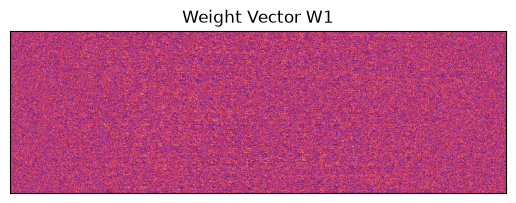

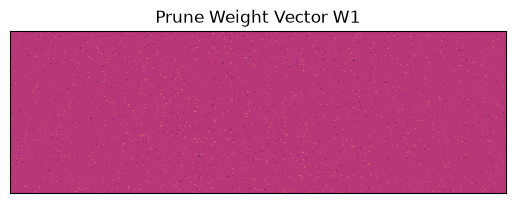

In [ ]:
# The value in which the lowest 99% are below

pruned_mlp = copy.deepcopy(mlp)
threshold = np.percentile(np.abs(mlp.W1), 99)
pruned_mlp.W1[np.abs(pruned_mlp.W1) < threshold] = 0



plt.title("Weight Vector W1")
plt.imshow(mlp.W1, cmap="magma")
plt.xticks([])
plt.yticks([])
plt.show()

plt.title("Prune Weight Vector W1")
plt.imshow(pruned_mlp.W1, cmap="magma")
plt.xticks([])
plt.yticks([])
plt.show()


In [48]:
# Exploring the effect different pruning levels have on the model:
thresholds = [0, 0.1, 0.3, 0.5, 0.7, 0.9]
accuracies = []

for amount in thresholds:
    pruned_mlp = copy.deepcopy(mlp)

    for param in ["W1", "b1", "W2", "b2"]:
        weights = getattr(pruned_mlp, param)

        threshold = np.percentile(
            np.abs(weights),
            amount * 100
        )

        weights[np.abs(weights) < threshold] = 0

    acc = accuracy(pruned_mlp, X_test, y_test)
    accuracies.append(acc)

    print(f"Pruned: {amount:.0%} - Accuracy: {acc:.4f}")

Pruned: 0% - Accuracy: 0.9454
Pruned: 10% - Accuracy: 0.9454
Pruned: 30% - Accuracy: 0.9450
Pruned: 50% - Accuracy: 0.9448
Pruned: 70% - Accuracy: 0.9216
Pruned: 90% - Accuracy: 0.7349


In [49]:
# Exploring the effect different quantisation levels have on the model:
bits_list = [8, 6, 4, 2]
accuracies = []

for bits in bits_list:
    quant_mlp = copy.deepcopy(mlp)

    levels = 2 ** (bits - 1) - 1

    for param in ["W1", "b1", "W2", "b2"]:
        values = getattr(quant_mlp, param)

        scale = np.max(np.abs(values)) / levels

        quantised = np.round(values / scale)
        quantised = np.clip(quantised, -levels, levels)

        setattr(quant_mlp, param, quantised * scale)

    acc = accuracy(quant_mlp, X_test, y_test)
    accuracies.append(acc)

    print(f"{bits}-bit accuracy: {acc:.4f}")

8-bit accuracy: 0.9450
6-bit accuracy: 0.9451
4-bit accuracy: 0.9447
2-bit accuracy: 0.3882


In [50]:
size_bytes_original = (
    mlp.W1.nbytes
    + mlp.b1.nbytes
    + mlp.W2.nbytes
    + mlp.b2.nbytes
)

print(f"Model size: {size_bytes_original / 1024:.2f} KB")

Model size: 1590.08 KB


In [53]:
import copy
import numpy as np

compressed_mlp = copy.deepcopy(mlp)

# Prune 50%
for param in ["W1", "b1", "W2", "b2"]:
    values = getattr(compressed_mlp, param)

    threshold = np.percentile(np.abs(values), 50)
    values[np.abs(values) < threshold] = 0


# Quantise to 4-bit
levels = 7

for param in ["W1", "b1", "W2", "b2"]:
    values = getattr(compressed_mlp, param)

    scale = np.max(np.abs(values)) / levels

    quantised = np.round(values / scale)
    quantised = np.clip(quantised, -levels, levels)

    setattr(compressed_mlp, param, quantised * scale)


# Test accuracy
acc = accuracy(compressed_mlp, X_test, y_test)
print(f"Accuracy: {acc:.4f}")


# Calculate theoretical compressed size
non_zero = sum(
    np.count_nonzero(getattr(compressed_mlp, param))
    for param in ["W1", "b1", "W2", "b2"]
)

size_bytes_shrunk = non_zero * 4 / 8

print(f"Compressed model size: {size_bytes_shrunk / 1024:.2f} KB")
print(f"Compressed model is {size_bytes_original / size_bytes_shrunk}x smaller")

Accuracy: 0.9402
Compressed model size: 49.69 KB
Compressed model is 32.0x smaller
